In [327]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, fbeta_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import wordnet
import re

mpl.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette('cubehelix')

LABELS_FONT_SIZE = 10
TITLE_FONT_SIZE = 12
SUP_TITLE_FONT_SIZE = 20
FONT_WEIGHT = 'bold'

In [328]:
# path = kagglehub.dataset_download("sbhatti/financial-sentiment-analysis")
# data_path = os.listdir(path)[0]
# full_path = os.path.join(path, data_path)
# print(f"Full Path: {full_path}")

In [329]:
df = pd.read_csv(r'C:\Users\ASUS\.cache\kagglehub\datasets\sbhatti\financial-sentiment-analysis\versions\4\data.csv')
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [330]:
df.shape

(5842, 2)

In [331]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

In [332]:
print('Duplicated Values:', df.duplicated().sum())

Duplicated Values: 6


In [333]:
df.drop_duplicates(inplace=True)

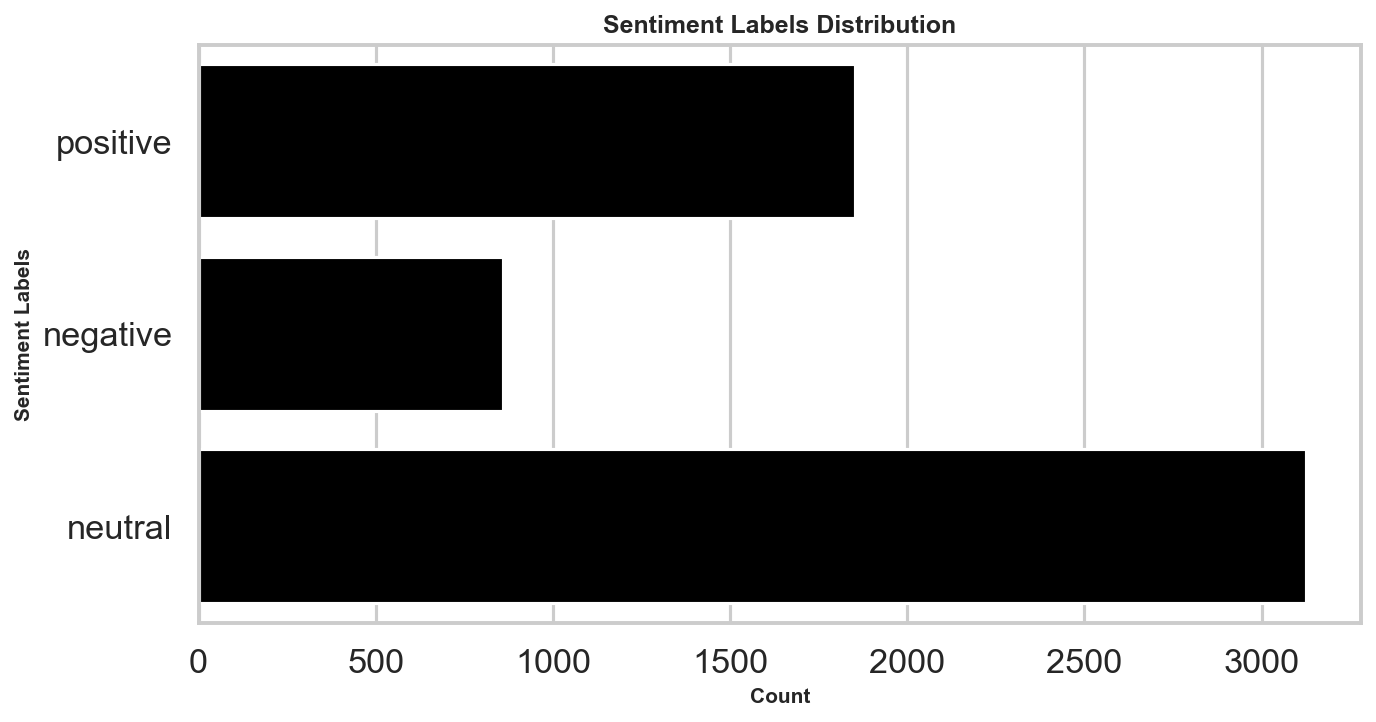

In [334]:
plt.figure(figsize=(10, 5))
sns.countplot(y=df['Sentiment'], color='black')

plt.title('Sentiment Labels Distribution', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xlabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.ylabel('Sentiment Labels', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.show()

In [335]:
email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
url_pattern = r'(?:https?://|www\.)[\w\.-]+\.[a-zA-Z]{2,}(?:/[\w\./_?=&#%-]*)?'
mention_pattern = r'@\w+'
tag_pattern = r'#\w+'

def find_emails(text):
    email = re.findall(email_pattern, text)
    if email:
        return email[0]

def find_urls(text):
    url = re.findall(url_pattern, text)
    if url:
        return url[0]

def find_mention(text):
    mention = re.findall(mention_pattern, text)
    if mention:
        return mention[0]
    
def find_tags(text):
    tag = re.findall(tag_pattern, text)
    if tag:
        return tag[0]
    
    
emails = []
urls = []
mentions = []
tags = []
for text in df['Sentence']:
    email = find_emails(text)
    if email is not None:
        emails.append(email)

    url = find_urls(text)
    if url is not None:
        urls.append(url)
    
    mention = find_mention(text)
    if mention is not None:
        mentions.append(mention)
        
    tag = find_tags(text)
    if tag is not None:
        tags.append(tag)

print('Emails:', len(emails))
print('URLs:', len(urls))
print('Mention:', len(mentions))
print('Tags:', len(tags))

Emails: 0
URLs: 279
Mention: 74
Tags: 43


In [336]:
print('mentions: \n', mentions)

mentions: 
 ['@cnnbrk', '@andrewnyquist', '@bman1', '@alphatrends', '@stockdemons', '@barronsonline', '@IfHeDiesHeDies', '@chessNwine', '@Dasan', '@HopeTurock', '@jimcramer', '@dandyduct', '@sharkbiotech', '@SOULLOR', '@saltwaternurse', '@RatingsNetwork', '@YahooFinance', '@21', '@scottrade', '@CH_Roark', '@asdfLLC', '@Marjo', '@ryandetrick', '@1nvestor', '@Binkster69', '@louiebeene', '@robbieLOLZ', '@jan', '@ShareStockNews', '@pierrules', '@Joerazorback', '@TheAcsMan', '@78', '@Intuitiv', '@NASDboy', '@Dojiknows', '@Dlerch', '@AllStarCharts', '@Renatta', '@mugatushair', '@BrooklynBandit', '@BVHealthcare', '@tsrandall', '@FletchTrade', '@StockTwits', '@TheStreet', '@vnoto74', '@ACInvestorBlog', '@ACInvestorBlog', '@totalguru', '@YahooFinance', '@technik', '@28', '@joemccann', '@Megaas2000', '@REC_Zakaria', '@Stockoptionexpert', '@gakrum', '@BULLYA', '@harmongreg', '@TraceyRyniec', '@StockTwits', '@Cash_Cow', '@moteltan', '@tomhend777', '@cheri1', '@RatingsNetwork', '@Yahoo', '@catskill

In [337]:
print('tags: \n', tags)

tags: 
 ['#software', '#BANG', '#FEDDAY', '#Apple', '#Outlook', '#Tesla', '#Apple', '#Trading', '#NASDAQ', '#NTAP', '#Fintech', '#NYSE', '#TSLA', '#tradeideas', '#windows', '#CEO', '#China', '#stocks', '#LongPos', '#Facebook', '#redtogreen', '#takeover', '#stocktrading', '#security', '#ModelX', '#traders', '#Tesla', '#UCB', '#OPEC', '#NDX', '#datasecurity', '#stockmarket', '#biotech', '#earnings', '#Esports', '#stocks', '#mining', '#bearish', '#FusionIQ', '#Apple', '#APPLE', '#correction', '#Amazon']


In [338]:
def text_preprocessing(text):
    text = str(text).lower()
    text = re.sub(r"\s+'s\b", " ", text)
    text = re.sub(r"'s\b", " ", text)
    text = re.sub(r"\s+'t\b", " not", text)
    text = re.sub(r"\s+'re\b", " are", text)
    text = re.sub(r"\s+'ve\b", " have", text)
    text = re.sub(r"\s+'ll\b", " will", text)
    text_urls_removed = re.sub(url_pattern, ' ', text)
    text_tags_removed = re.sub(tag_pattern, ' ', text_urls_removed)
    text_mentions_removed = re.sub(mention_pattern, ' ', text_tags_removed)
    text_cleaned = re.sub(r'[^a-zA-Z\s]', ' ', text_mentions_removed)
    text_cleaned = re.sub(r'[^a-z\s]', ' ', text_cleaned)
    final_text = re.sub(r"\s+", " ", text_cleaned).strip()
    return final_text
    
df['sentence_cleaned'] = df['Sentence'].apply(text_preprocessing)

In [339]:
def create_wordcloud(text):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate(text)
    
    return wordcloud

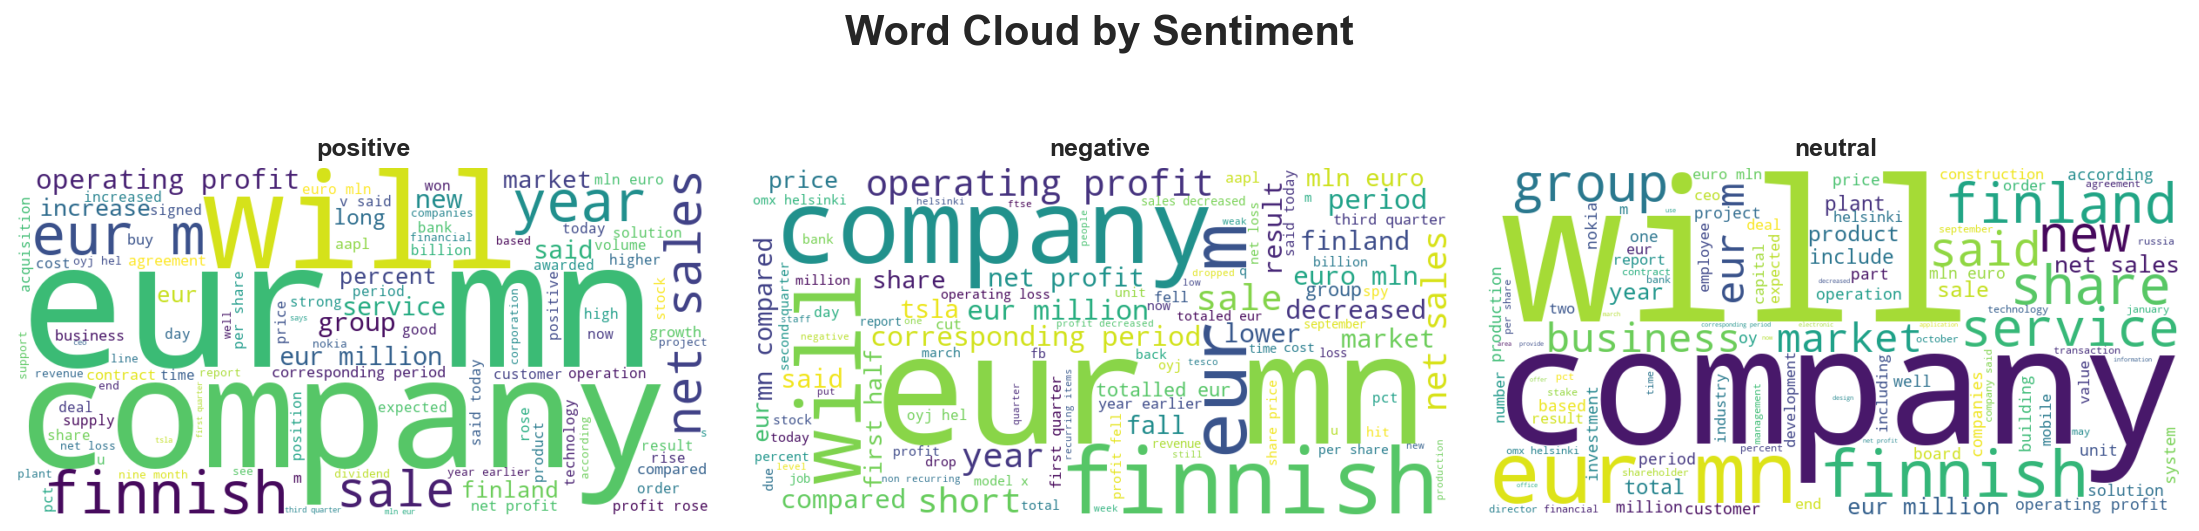

In [340]:
labels = df['Sentiment'].unique()

fig, axes = plt.subplots(nrows=1, ncols=len(labels), figsize=(15, 4))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    text = ' '.join(df[df['Sentiment'] == label]['sentence_cleaned'].tolist())
    
    wordcloud = create_wordcloud(text)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(label, fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.axis('off')
    
plt.suptitle('Word Cloud by Sentiment', fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

In [341]:
df.isnull().sum()

Sentence            0
Sentiment           0
sentence_cleaned    0
dtype: int64

In [342]:
def get_rare_words(n=5):
    words = ' '.join(X_train.tolist()).split()
    words_count = dict(Counter(words))
    rare_words = set(word for word, v in words_count.items() if v <= n)
    
    return rare_words

def remove_rare_words(X, rare_words):
    words = X.split()
    rares_removed = [word for word in words if word not in rare_words]
    final_text = ' '.join(rares_removed)
    
    return final_text

In [343]:
stemmer = SnowballStemmer('english')

def stemming(text):
    tokens = word_tokenize(text)
    stemmed_words = [stemmer.stem(token) for token in tokens]
    final_text = ' '.join(stemmed_words)
    return final_text

In [344]:
X = df['sentence_cleaned']
y = df['Sentiment']

lb_encoder = LabelEncoder()
y = lb_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

rare_words = get_rare_words(n=5)

X_train_cleaned = X_train.apply(lambda x: remove_rare_words(x, rare_words))
X_test_cleaned = X_test.apply(lambda x: remove_rare_words(x, rare_words))

print('Class Codes:', list(zip(lb_encoder.classes_, lb_encoder.transform(lb_encoder.classes_))))

Class Codes: [('negative', 0), ('neutral', 1), ('positive', 2)]


In [345]:
def create_confusion_matrix(y_true, y_predictions, annot_size=15, ticks_size=15, color='black'):
    fig, ax = plt.subplots(figsize=(11, 5))
    
    cm = confusion_matrix(y_true, y_predictions, labels=[0, 1, 2])
    
    ticks_label = ['Negative', 'Neutral', 'Positive']
    
    group_names = [
        'TP(neg)', 'FP(neu→neg)', 'FP(pos→neg)',
        'FP(neg→neu)', 'TP(neu)', 'FP(pos→neu)',
        'FP(neg→pos)', 'FP(neu→pos)', 'TP(pos)'
    ]
    
    cm_values = [value for value in cm.flatten()]
    cm_labels = [f'{label}\n{val}' for val, label in zip(cm_values, group_names)]
    cm_labels = np.array(cm_labels).reshape([3, 3])
    
    custom_cmap = LinearSegmentedColormap.from_list(
        'finpulse',
        colors=['#f8f9fa', '#adb5bd', '#495057', '#212529'],
        N=256
    )
    
    sns.heatmap(cm, xticklabels=ticks_label, yticklabels=ticks_label,
                ax=ax, annot=cm_labels, fmt='',
                annot_kws={"size": annot_size, "color": color, "fontweight": FONT_WEIGHT},
                cmap=custom_cmap,
                linewidths=2,
                linecolor='#0f0f0f')
    
    ax.set_title('Confusion Matrix', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT, color='black')
    ax.tick_params(axis='both', labelsize=ticks_size, colors=color)
    ax.set_xlabel('Predicted', fontsize=LABELS_FONT_SIZE, color=color, fontweight=FONT_WEIGHT,)
    ax.set_ylabel('True', fontsize=LABELS_FONT_SIZE, color=color, fontweight=FONT_WEIGHT,)
    ax.spines[:].set_edgecolor('white')
    plt.tight_layout()
    plt.show()

In [346]:
def evaluate_predictions(y_true, y_predictions, y_probs):
    cr_imbalanced = classification_report_imbalanced(y_true, y_predictions, target_names=['Negative', 'Neutral', 'Positive'])
    f2_macro = fbeta_score(y_true, y_predictions, beta=2, average='macro')
    avg_pr = average_precision_score(y_true, y_probs, average='macro')
    
    print(cr_imbalanced)
    print('F2 macro:', f2_macro)
    print('Average precision:', avg_pr)
    
    create_confusion_matrix(y_true, y_predictions)

## Baseline Model

In [347]:
X_train_stemmed = X_train_cleaned.apply(stemming)
X_test_stemmed = X_test_cleaned.apply(stemming)

X_train_stemmed.head()

4256    raut headquart in finland is a technolog compa...
5712    lead product in turn should increas to tonn th...
3005                         news on strong glencor bp in
483     it come complet with an touch screen system fo...
2971                     long setup report veri good earn
Name: sentence_cleaned, dtype: object

In [348]:
vocab_size = 5000

tfidf_vectorizer = CountVectorizer(
    lowercase=False, 
    stop_words=None, 
    ngram_range=(1, 2),
    max_features=vocab_size
)

X_train_vectorized = tfidf_vectorizer.fit_transform(X_train_stemmed)
X_test_vectorized = tfidf_vectorizer.transform(X_test_stemmed)

                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.38      0.43      0.88      0.40      0.62      0.36       172
    Neutral       0.79      0.77      0.76      0.78      0.77      0.59       625
   Positive       0.73      0.71      0.88      0.72      0.79      0.62       371

avg / total       0.71      0.70      0.81      0.71      0.75      0.56      1168

F2 macro: 0.6369553799699732
Average precision: 0.664146940516234


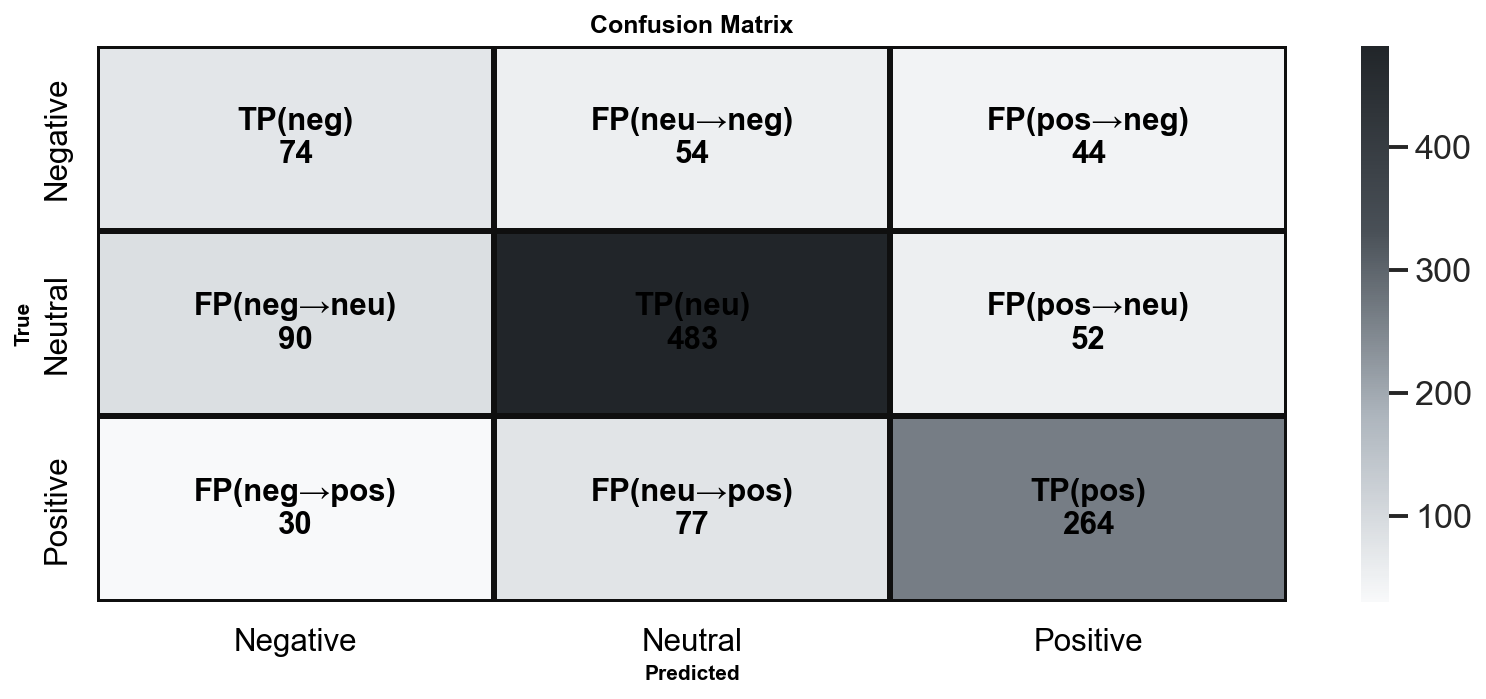

In [349]:
nb_normal = MultinomialNB()
nb_normal.fit(X_train_vectorized, y_train)

y_prob = nb_normal.predict_proba(X_test_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)

## Cost-Sensitive Learning

#### Sample Weight

                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.36      0.52      0.84      0.42      0.66      0.42       172
    Neutral       0.82      0.73      0.81      0.77      0.77      0.58       625
   Positive       0.71      0.70      0.87      0.71      0.78      0.60       371

avg / total       0.72      0.69      0.83      0.70      0.76      0.56      1168

F2 macro: 0.6397074642576458
Average precision: 0.6532054719948629


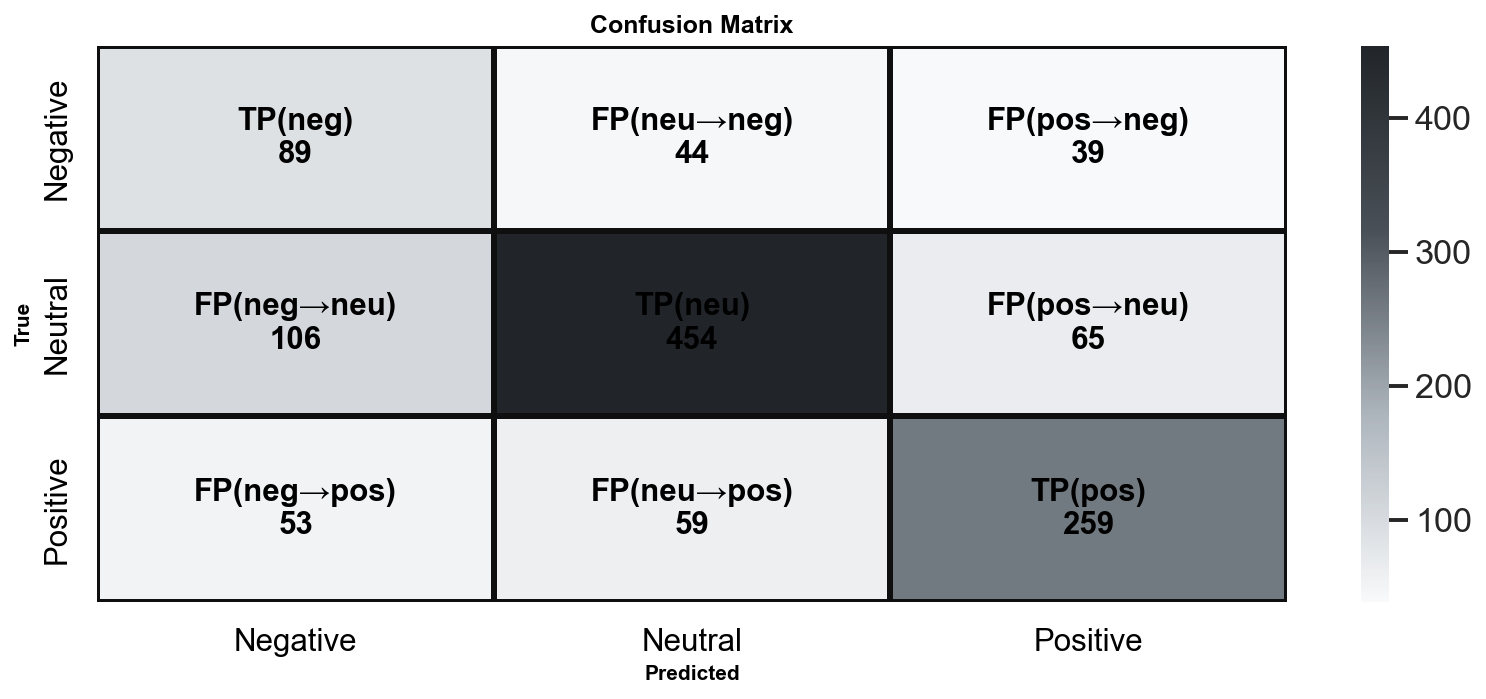

In [350]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nb_weighted = MultinomialNB()
nb_weighted.fit(X_train_vectorized, y_train, sample_weight=sample_weights)

y_prob = nb_weighted.predict_proba(X_test_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)

### MetaCost

In [351]:
class MetaCost:
    def __init__(self, classifier, cost_matrix, n_iter=10, sample_frac=0.7, random_state=None):
        self.classifier = classifier
        self.cost_matrix = np.array(cost_matrix)
        self.n_iter = n_iter
        self.sample_frac = sample_frac
        self.random_state = random_state
        self.final_model = None

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        
        n_samples = X.shape[0]
        n_classes = self.cost_matrix.shape[0]
        
        prob_sum = np.zeros((n_samples, n_classes))

        for _ in range(self.n_iter):
            idx = rng.choice(n_samples,
                            int(n_samples * self.sample_frac),
                            replace=True)
            model = clone(self.classifier)
            model.fit(X[idx], y[idx])
            prob_sum += model.predict_proba(X)

        probs = prob_sum / self.n_iter

        expected_cost = probs @ self.cost_matrix
        new_labels = np.argmin(expected_cost, axis=1)

        self.final_model = clone(self.classifier)
        self.final_model.fit(X, new_labels)
        
        return self

    def predict(self, X):
        return self.final_model.predict(X)

    def predict_proba(self, X):
        return self.final_model.predict_proba(X)

                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.32      0.51      0.82      0.39      0.64      0.40       172
    Neutral       0.79      0.74      0.78      0.76      0.76      0.57       625
   Positive       0.66      0.57      0.87      0.61      0.70      0.48       371

avg / total       0.68      0.65      0.81      0.66      0.72      0.52      1168

F2 macro: 0.595098431475794
Average precision: 0.6039306745644794


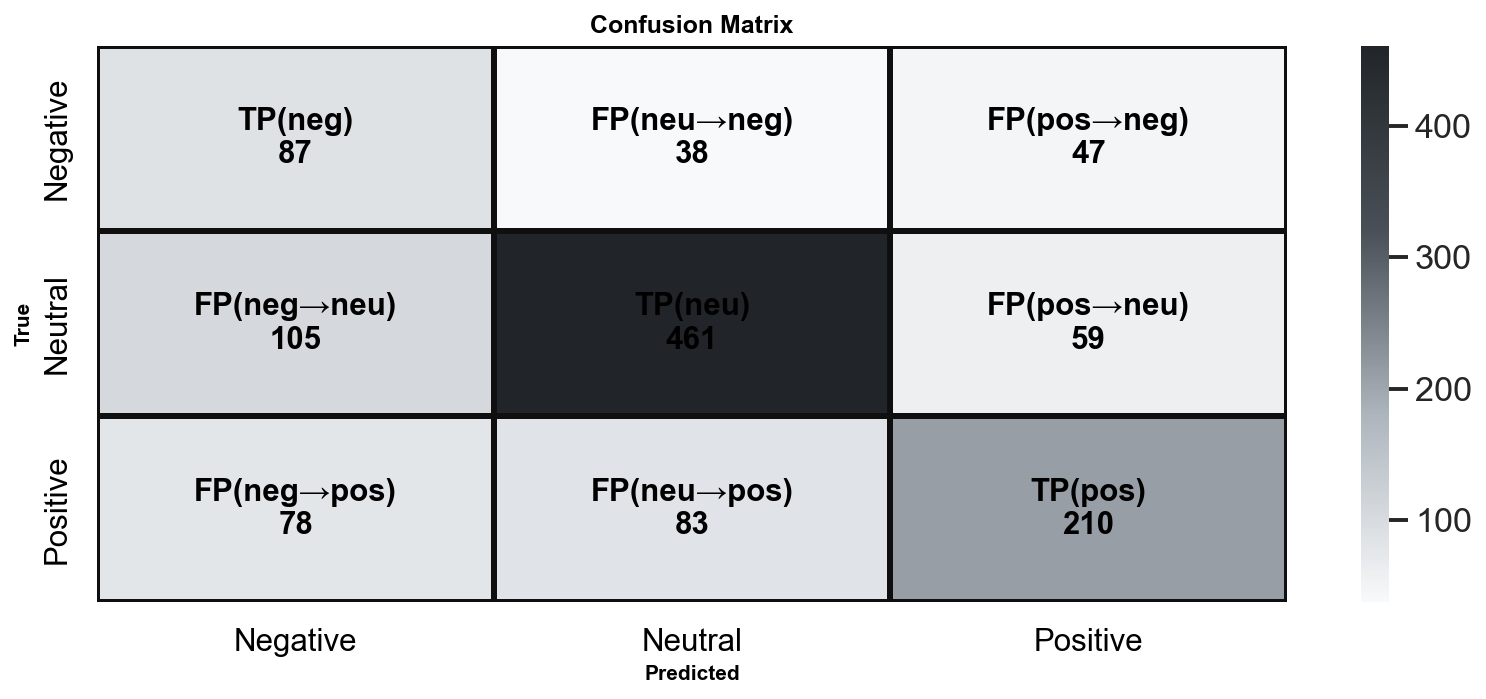

In [352]:
cost_matrix = [
    [0,  6,  6],
    [1,  0,  1],
    [2,  1,  0]
]

meta_cost = MetaCost(MultinomialNB(), cost_matrix, n_iter=10, sample_frac=0.7, random_state=42)
meta_cost.fit(X_train_vectorized, y_train)

y_prob = meta_cost.predict_proba(X_test_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)

## Bagging

                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.38      0.48      0.86      0.42      0.64      0.40       172
    Neutral       0.80      0.76      0.78      0.78      0.77      0.59       625
   Positive       0.73      0.70      0.88      0.71      0.78      0.60       371

avg / total       0.71      0.70      0.82      0.71      0.75      0.56      1168

F2 macro: 0.6414933415536663
Average precision: 0.668688684938259


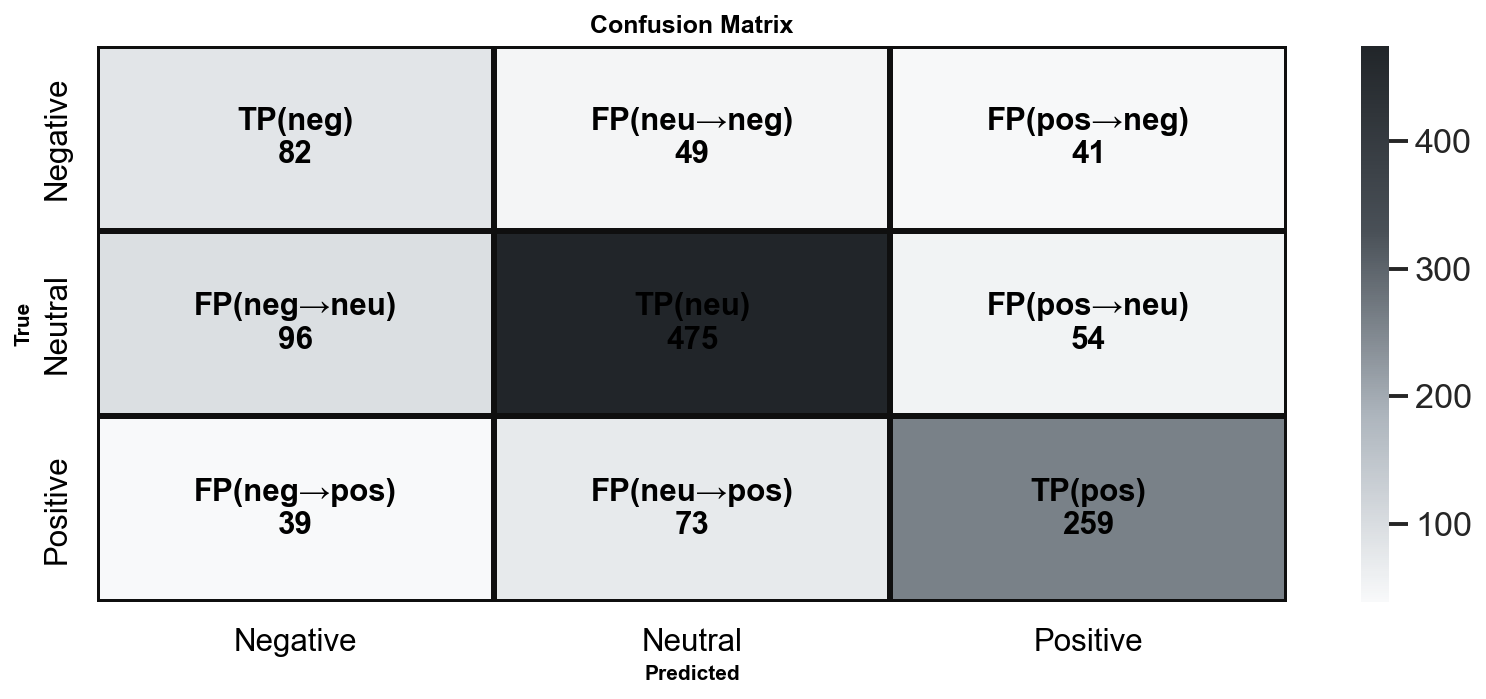

In [353]:
bagging_oversampler = BalancedBaggingClassifier(
    estimator=MultinomialNB(), 
    n_estimators=50, 
    sampler=RandomOverSampler(), 
    random_state=42,
    n_jobs=-1
)

bagging_oversampler.fit(X_train_vectorized, y_train)

y_prob = bagging_oversampler.predict_proba(X_test_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)

                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.36      0.56      0.83      0.44      0.68      0.45       172
    Neutral       0.82      0.72      0.82      0.77      0.77      0.59       625
   Positive       0.70      0.67      0.87      0.68      0.76      0.57       371

avg / total       0.72      0.68      0.84      0.69      0.75      0.56      1168

F2 macro: 0.6398485330725345
Average precision: 0.661166862352398


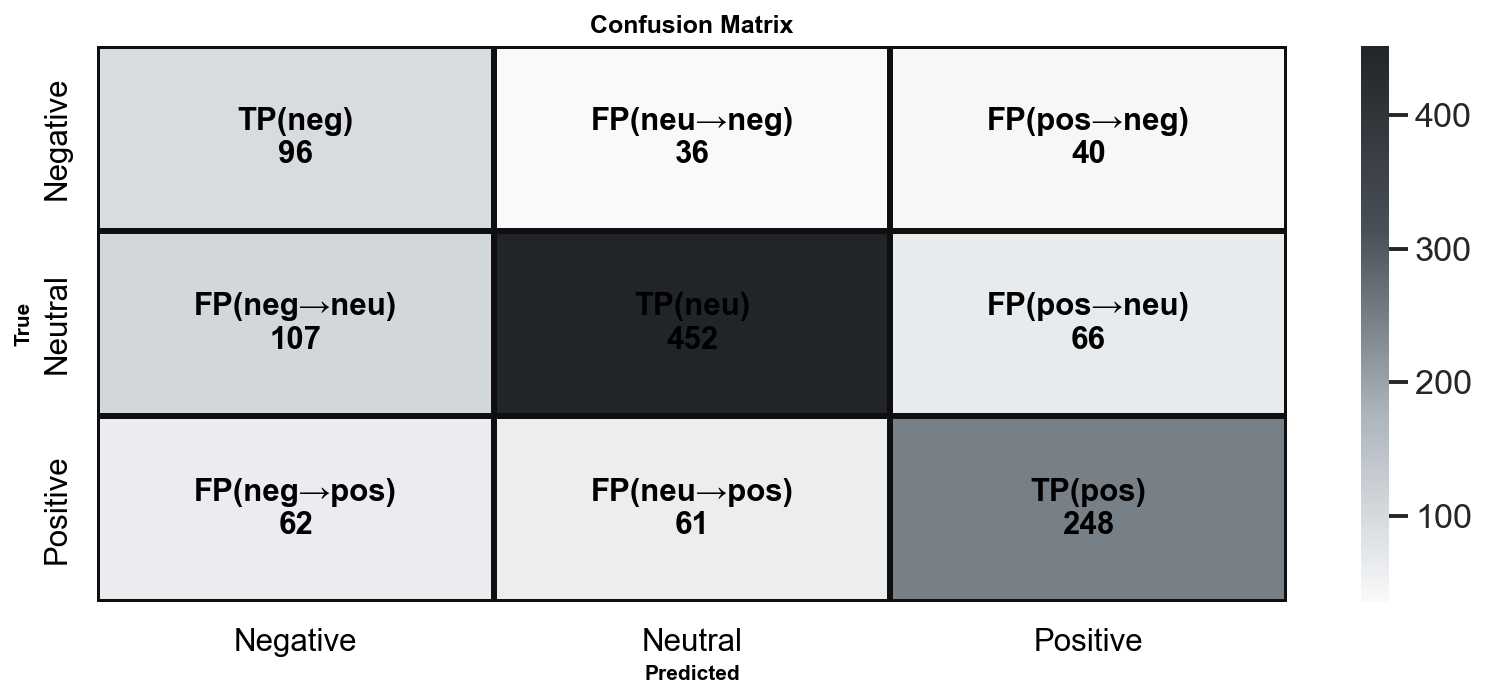

In [354]:
bagging_undersampler = BalancedBaggingClassifier(
    estimator=MultinomialNB(), 
    n_estimators=50, 
    sampler=RandomUnderSampler(), 
    random_state=42,
    n_jobs=-1
)

bagging_undersampler.fit(X_train_vectorized, y_train)

y_prob = bagging_undersampler.predict_proba(X_test_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)

## Data Augmentation

### OverSampling

In [355]:
random_sampler = RandomOverSampler(random_state=42)

X_train_oversampled, y_train_oversampled = random_sampler.fit_resample(X_train_vectorized, y_train)

print(dict(Counter(y_train_oversampled)))

{1: 2499, 2: 2499, 0: 2499}


                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.36      0.48      0.85      0.41      0.64      0.39       172
    Neutral       0.80      0.72      0.79      0.76      0.76      0.57       625
   Positive       0.69      0.69      0.86      0.69      0.77      0.58       371

avg / total       0.70      0.68      0.82      0.69      0.74      0.55      1168

F2 macro: 0.625840087341084
Average precision: 0.6471812714102191


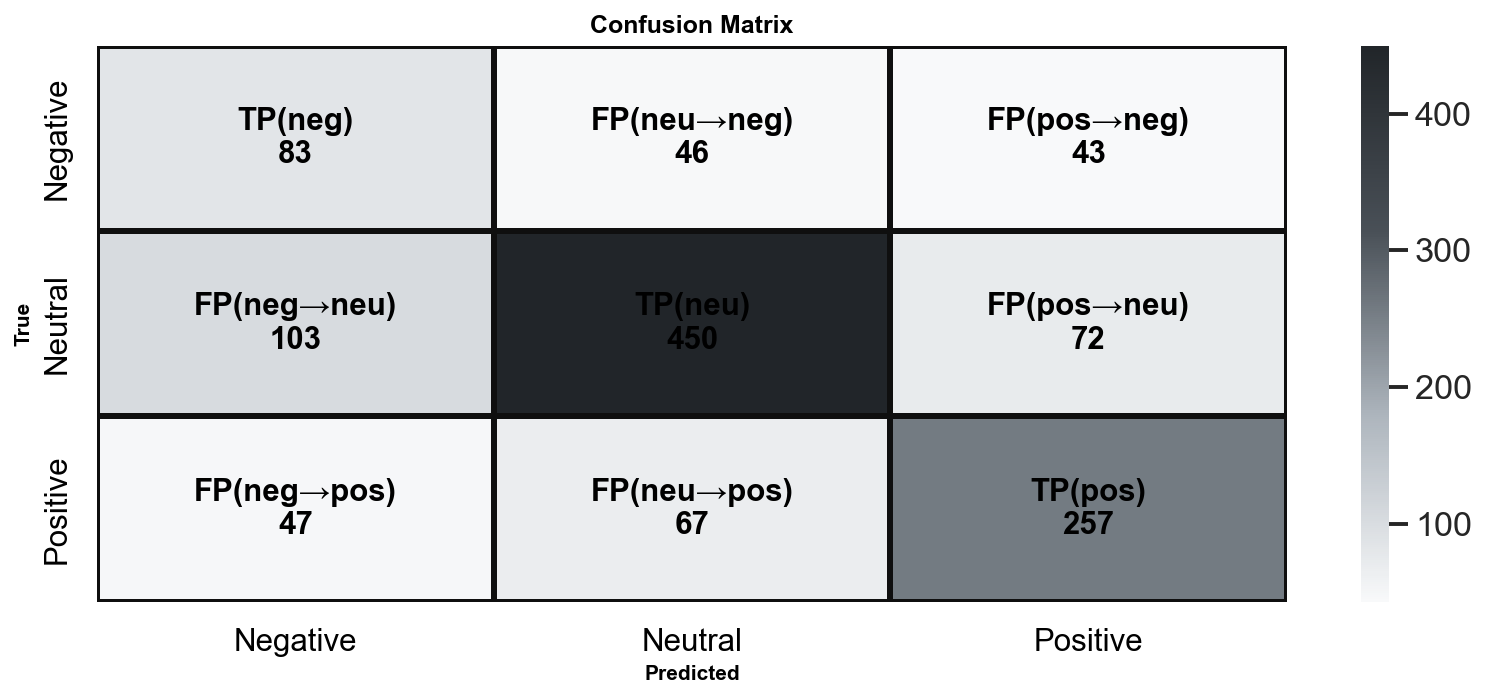

In [356]:
nb_oversampled = MultinomialNB()
nb_oversampled.fit(X_train_oversampled, y_train_oversampled)

y_prob = nb_oversampled.predict_proba(X_test_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)

### Synonyms

In [357]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ')
            if synonym.lower() != word.lower():
                synonyms.add(synonym)
    return synonyms

def augment_with_synonyms(text, n=2):
    words = text.split()
    new_words = words.copy()
    unique_shuffled_words = list(set(words))
    np.random.shuffle(unique_shuffled_words)
        
    num_replaced = 0
    for random_word in unique_shuffled_words:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = np.random.choice(list(synonyms))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
            
    return ' '.join(new_words)

In [358]:
labels_count = dict(Counter(y_train))

majority_class = max(labels_count, key=labels_count.get)
majority_class_count = labels_count.get(majority_class)
labels_count.pop(majority_class)

data = pd.concat([X_train_cleaned.reset_index(drop=True), pd.Series(y_train, name='label')], axis=1)

augmented_data = []
for cls in labels_count:
    distance = majority_class_count - labels_count.get(cls)
    texts = data.query(f'label == {cls}')
    datas_to_augment = texts.sample(n=distance, replace=True, random_state=42)
    
    for idx, row in datas_to_augment.iterrows():
        text = row.iloc[0]
        label = row['label']
        augmented_text = augment_with_synonyms(text)
        augmented_data.append((augmented_text, label))

data = pd.concat(
    [data, pd.DataFrame(augmented_data)
            .rename(columns={0: 'sentence_cleaned', 1: 'label'})
            .reset_index(drop=True)], axis=0
)

In [359]:
data = data.sample(frac=1, random_state=42)

X_train_augmented = data.drop('label', axis=1)
y_train_augmented = data['label']

In [360]:
X_train_aug_stemmed = X_train_augmented.iloc[:, 0].apply(augment_with_synonyms)

In [361]:
vocab_size = 10000

tfidf_vectorizer = TfidfVectorizer(
    lowercase=False, 
    stop_words=None, 
    ngram_range=(1, 2),
    max_features=vocab_size
)

X_train_aug_vectorized = tfidf_vectorizer.fit_transform(X_train_aug_stemmed)
X_test_aug_vectorized = tfidf_vectorizer.transform(X_test_stemmed)

                   pre       rec       spe        f1       geo       iba       sup

   Negative       0.34      0.50      0.84      0.41      0.65      0.40       172
    Neutral       0.77      0.75      0.74      0.76      0.74      0.55       625
   Positive       0.65      0.54      0.87      0.59      0.68      0.45       371

avg / total       0.67      0.65      0.79      0.65      0.71      0.50      1168

F2 macro: 0.5896463957342913
Average precision: 0.6081789355066339


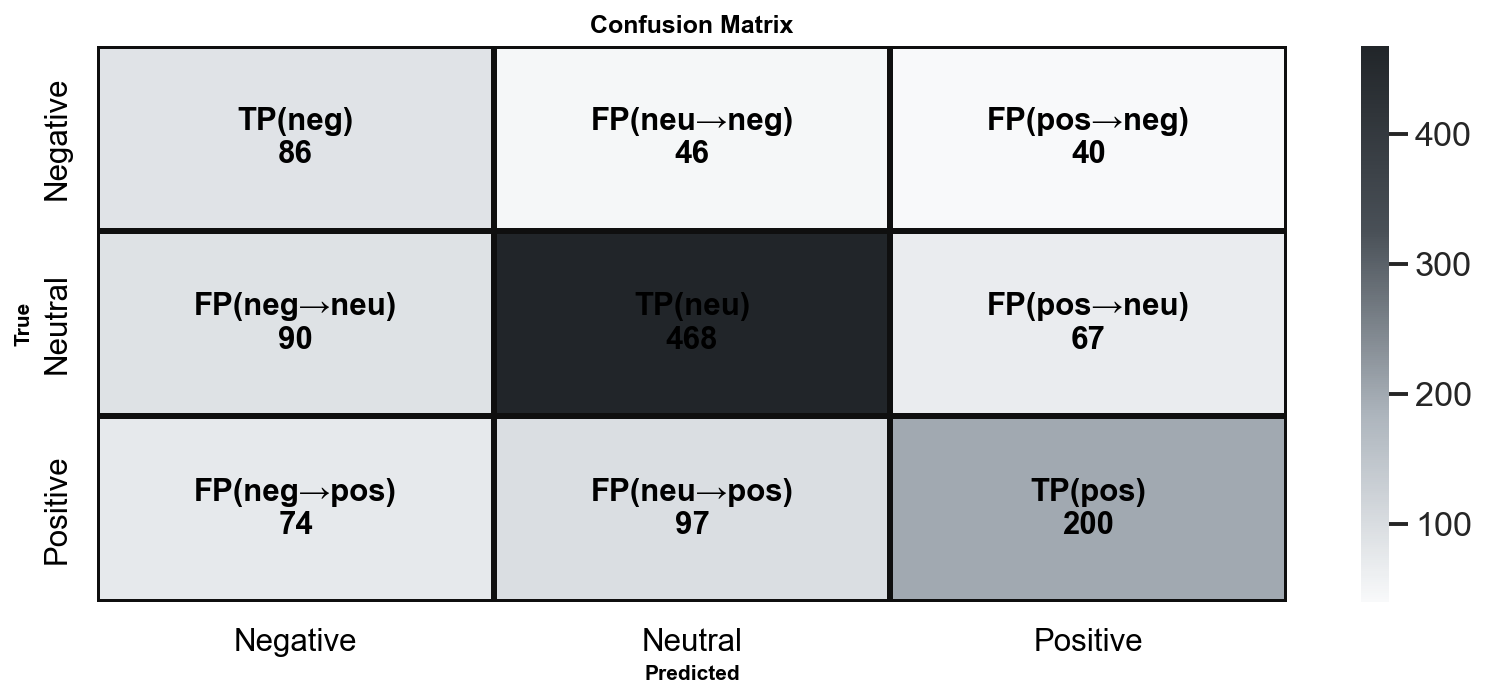

In [362]:
nb_oversampled = MultinomialNB()
nb_oversampled.fit(X_train_aug_vectorized, y_train_augmented)

y_prob = nb_oversampled.predict_proba(X_test_aug_vectorized)

evaluate_predictions(y_test, np.argmax(y_prob, axis=1), y_probs=y_prob)